In [1]:
print("hello world")

hello world


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# pip install openpyxl

In [10]:
data = pd.read_csv("salary.csv")

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


In [11]:
data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [12]:
print("\nShape of Dataset:")
print(data.shape)


Shape of Dataset:
(30, 2)


In [13]:
print("\nFirst 5 Rows:")
print(data.head())


First 5 Rows:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [14]:
print("\nLast 5 Rows:")
print(data.tail())



Last 5 Rows:
    YearsExperience  Salary
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872


In [15]:
print("\nRandom Sample:")
print(data.sample(5))


Random Sample:
    YearsExperience  Salary
19              6.0   93940
28             10.3  122391
27              9.6  112635
12              4.0   56957
20              6.8   91738


In [16]:
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None


In [17]:
print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


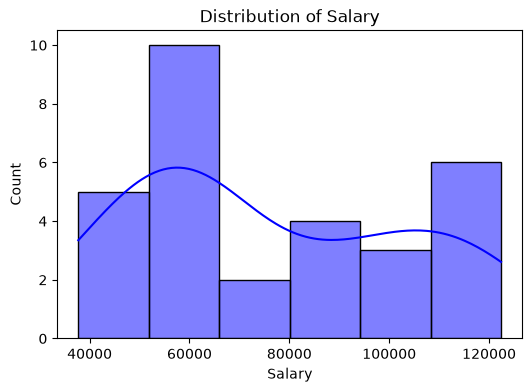

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(data["Salary"], kde=True, color="blue")
plt.title("Distribution of Salary")
plt.show()



Missing Values:
YearsExperience    0
Salary             0
dtype: int64


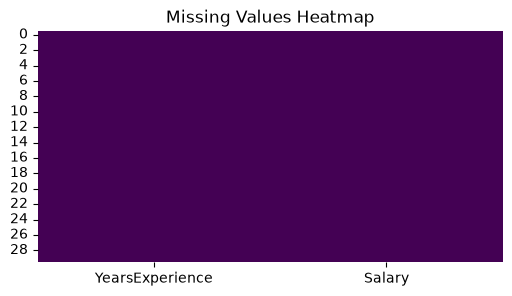

In [19]:
print("\nMissing Values:")
print(data.isnull().sum())

plt.figure(figsize=(6,3))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

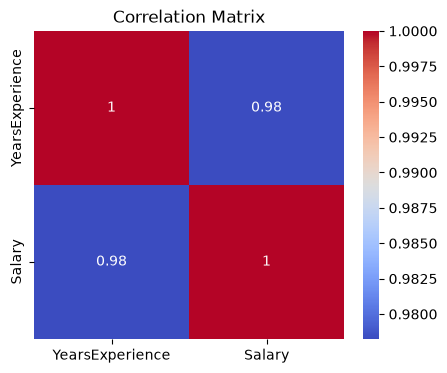

In [20]:
plt.figure(figsize=(5,4))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

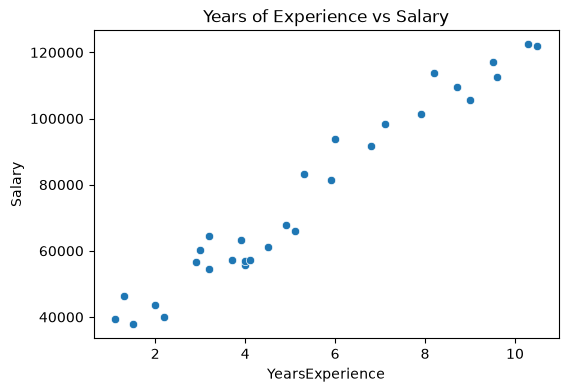

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="YearsExperience",
                y="Salary",
                data=data)
plt.title("Years of Experience vs Salary")
plt.show()

In [22]:
X = data.drop("Salary", axis=1)
y = data["Salary"]

In [23]:
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

print("\nFeatures after removing ID column:")
print(X.columns)



Features after removing ID column:
Index(['YearsExperience'], dtype='str')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)








Training data: (24, 1)
Testing data: (6, 1)


In [25]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nNumerical Features:", numerical_features)
print("Categorical Features:", categorical_features)




Numerical Features: Index(['YearsExperience'], dtype='str')
Categorical Features: Index([], dtype='str')


In [26]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [27]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


In [29]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regression", LinearRegression())
])


In [30]:
model.fit(X_train, y_train)
print("\nModel Trained Successfully!")




Model Trained Successfully!


In [31]:
y_pred = model.predict(X_test)

print("\nPredicted Salary Values:")
print(y_pred)



Predicted Salary Values:
[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [32]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Evaluation
MAE  : 6286.453830757749
RMSE : 7059.04362190151
R2 Score : 0.9024461774180497



Actual vs Predicted Salary
   Actual Salary  Predicted Salary
0         112635     115790.210113
1          67938      71498.278095
2         113812     102596.868661
3          83088      75267.804224
4          64445      55477.792045
5          57189      60189.699707


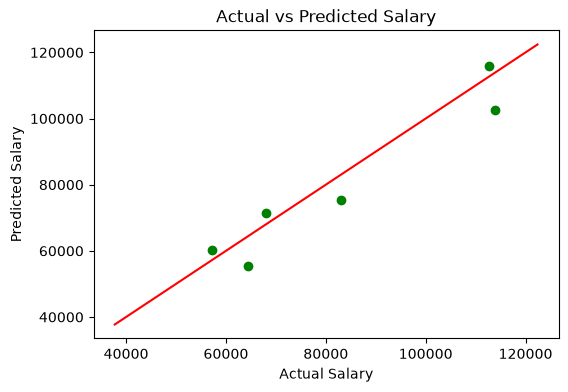

In [33]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

print("\nActual vs Predicted Salary")
print(comparison)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color="green")
plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color="red")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()



In [35]:
sample = pd.DataFrame({
    "YearsExperience": [5]
})

predicted_salary = model.predict(sample)

print("\nPredicted Salary for 5 Years Experience:")
print(predicted_salary[0])


Predicted Salary for 5 Years Experience:
72440.6596269317
